# Eurofer_CD — Cluster Dynamics for bcc Fe / EUROFER97
## Python + C++ SUNDIALS solvers (mirrors Full_CD/codes/CD_4_windows.ipynb)

**Physics**: Ghoniem, N.M. (2024), *Formulation of Cluster Dynamics Equations for
Irradiated Ferritic-Martensitic Steels*, Sections 1–5.

**State vector**: `[Ci1..Ci_Ni, Cv1..Cv_Nv, C_He]`  — `N = Ni + Nv + 1` equations

### Solver modes
| MODE | Backend | Description |
|------|---------|-------------|
| `py_segments` | Python LSODA | Segmented, x_max-gated (existing py_utils) |
| `cpp_full` | C++ CVODE BDF | Full system, dense/band/GMRES linear solver |
| `cpp_expand_front` | C++ CVODE BDF | Phase I: upper-truncation window on SIA |
| `cpp_sliding_win` | C++ CVODE BDF | Phase III: constant-width sliding window |
| `sliding_OpenMP` | C++ CVODE BDF | Phase IV: Phase III + OpenMP |

### Build the C++ solver
```bash
cd Eurofer_CD/cpp_utils
cmake -S . -B ../build -DCMAKE_BUILD_TYPE=Release
cmake --build ../build --config Release
```

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 0 — Configuration  (edit here, then run all cells below)
# ─────────────────────────────────────────────────────────────────────────────

# ── Solver mode ───────────────────────────────────────────────────────────────
# 'py_segments'      — Python LSODA, segmented (Cell 1)
# 'cpp_full'         — C++ CVODE BDF, full system, dense or GMRES (Cell 2)
# 'cpp_expand_front' — C++ CVODE BDF, Phase I upper-truncation window (Cell 3)
# 'cpp_sliding_win'  — C++ CVODE BDF, Phase III constant-width window (Cell 4)
# 'sliding_OpenMP'   — C++ CVODE BDF, Phase IV = Phase III + OpenMP (Cell 5)
MODE = 'cpp_full'

# ── Problem size ──────────────────────────────────────────────────────────────
NI = 200        # max SIA cluster size
NV = 200       # max vacancy cluster size
HE_MODE = 'decoupled'   # 'decoupled' | 'fast_eq'

# ── Simulation time span ──────────────────────────────────────────────────────
T_SPAN  = (1e-8, 1e4)   # (t0, tf) [s]
N_PTS   = 200           # output time points
LOG_T   = True          # logarithmically spaced output

# ── ODE tolerances ────────────────────────────────────────────────────────────
RTOL = 1e-5
ATOL = 1e-30

# ── Physics overrides (None → use Excel defaults) ────────────────────────────
OVERRIDES = {
    # 'T':     773.0,   # temperature [K]
    # 'G':     1e-6,    # damage rate [dpa/s]
     'rho_d': 5e12,    # dislocation density [m^-2]
}

# ── C++ solver method options ─────────────────────────────────────────────────
# These are passed as 'solver_method' inside SOLVER_CONFIG.
# They are ignored by the Python LSODA mode.
SOLVER_METHOD = {
    # ── Full system (cpp_full) ────────────────────────────────────────────────
    'backend':   'cvode',      # 'cvode' | 'arkode'
    'lmm':       'bdf',        # 'bdf' (stiff) | 'adams'
    'linsol':    'gmres',      # 'dense' (small N) | 'gmres' (large N)

    # ── Phase I (cpp_expand_front) ────────────────────────────────────────────
    # 'window_mode':       1,
    # 'window_w0_i':       50,      # initial SIA window size
    # 'window_C_expand':   1e-20,   # expand when C[x_hi] > this
    # 'window_expand_pad': 20,      # cluster sizes to add per expansion
    # 'window_prec':       1,       # 1 = SMW-Jacobi preconditioner for GMRES

    # ── Phase III (cpp_sliding_win) ───────────────────────────────────────────
    'window_mode':       3,
    'window_w0_i':       50,      # initial SIA window size; expands as distribution grows
    'window_width':      300,     # constant window width (after window_t_start)
    'window_t_start':    1.0,     # suppress lower sliding until t > this [s]
    'window_N_thresh':   1000,    # activate Phase III only if Ni > this
    'window_C_expand':   1e-20,
    'window_expand_pad': 50,
    'window_prec':       1,
    'window_gmres_maxl': 20,      # GMRES Krylov subspace size (SUNDIALS default=5, use 20+)

    # ── Phase IV (sliding_OpenMP) ─────────────────────────────────────────────
    # 'window_mode':        4,
    # 'window_omp_threads': 0,    # 0 = OMP_NUM_THREADS, >0 = explicit
}

# ── MODE → window_mode mapping (overrides SOLVER_METHOD['window_mode']) ──────
_MODE_WINDOW = {
    'py_segments':       None,
    'cpp_full':          0,
    'cpp_expand_front':  1,
    'cpp_sliding_win':   3,
    'sliding_OpenMP':    4,
}
if MODE in _MODE_WINDOW and _MODE_WINDOW[MODE] is not None:
    SOLVER_METHOD['window_mode'] = _MODE_WINDOW[MODE]

# For full system, use dense for small N, GMRES for large N
if MODE == 'cpp_full':
    SOLVER_METHOD['linsol'] = 'dense' if (NI + NV + 1) <= 500 else 'gmres'

# ── Assembled solver config (passed to cpp_bridge.run_cpp_solver) ────────────
SOLVER_CONFIG = {
    't_span':        T_SPAN,
    'n_points':      N_PTS,
    'log_time':      LOG_T,
    'rtol':          RTOL,
    'atol':          ATOL,
    'solver_method': SOLVER_METHOD,
}

print(f"MODE = {MODE!r}")
print(f"Problem: Ni={NI}, Nv={NV}, he_mode={HE_MODE!r}, N_EQ={NI+NV+1}")
print(f"t_span = {T_SPAN},  n_points = {N_PTS}")
print(f"rtol = {RTOL:.0e},  atol = {ATOL:.0e}")
print(f"solver_method = {SOLVER_METHOD}")

MODE = 'cpp_full'
Problem: Ni=200, Nv=200, he_mode='decoupled', N_EQ=401
t_span = (1e-08, 10000.0),  n_points = 200
rtol = 1e-05,  atol = 1e-30
solver_method = {'backend': 'cvode', 'lmm': 'bdf', 'linsol': 'dense', 'window_mode': 0, 'window_w0_i': 50, 'window_width': 300, 'window_t_start': 1.0, 'window_N_thresh': 1000, 'window_C_expand': 1e-20, 'window_expand_pad': 50, 'window_prec': 1, 'window_gmres_maxl': 20}


## Common imports & initialisation

In [10]:
import sys
sys.path.insert(0, '../../')

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from Eurofer_CD.py_utils.simulation    import EuroferCDSimulation
from Eurofer_CD.py_utils.visualization import EuroferCDVisualizer, create_run_directory, write_provenance
from Eurofer_CD.py_utils               import post_process

# Initialise simulation (loads Excel, pre-computes rate arrays)
sim_kwargs = {'Ni': NI, 'Nv': NV, 'he_mode': HE_MODE}
if OVERRIDES:
    # Build a temporary Excel override by patching after loading
    sim = EuroferCDSimulation(**sim_kwargs)
    for k, v in OVERRIDES.items():
        sim.input_data.material_params[k] = v
        sim.input_data.material_env[k]    = v
    # Re-derive
    sim.input_data.calculate_derived_parameters()
    from Eurofer_CD.py_utils.reaction_rates import ReactionRates
    from Eurofer_CD.py_utils.rate_equations import RateEquations
    sim.reaction_rates = ReactionRates(sim.input_data)
    sim.rate_equations = RateEquations(sim.input_data, sim.reaction_rates)
else:
    sim = EuroferCDSimulation(**sim_kwargs)

print(f"\nInitialisation complete — {sim.rate_equations.N} ODE equations")

Initializing Eurofer_CD simulation…
Loading parameters from: C:\Users\Owner\Documents\Repos\EuroferMicrostructure\Eurofer_CD\input\input_parameters.xlsx
Successfully loaded all three parameter sheets.
Derived:  T=673.0 K  Cv_eq=1.109e-13  Di=2.342e-09 m2/s  Dv=7.915e-12 m2/s  he_mode='decoupled'
ReactionRates: KVV[0]=4.767e+09  KII[0]=7.054e+11  GVV[0]=5.286e-04  GVV[1]=7.231e+08
  k2_disl_v=7.915e+00  k2_disl_i=2.460e+03  k2_disl_He=8.782e+02
  K_IclV[1,0]=3.985e+11  K_IclV[1,1]=4.444e+11  (n=2 SIA cluster <-> vacancy cluster)
RateEquations: N=401 (Ni=200, Nv=200, He=1)  he_mode='decoupled'
Simulation initialized successfully.
Derived:  T=673.0 K  Cv_eq=1.109e-13  Di=2.342e-09 m2/s  Dv=7.915e-12 m2/s  he_mode='decoupled'
ReactionRates: KVV[0]=4.767e+09  KII[0]=7.054e+11  GVV[0]=5.286e-04  GVV[1]=7.231e+08
  k2_disl_v=3.958e+01  k2_disl_i=1.230e+04  k2_disl_He=4.391e+03
  K_IclV[1,0]=3.985e+11  K_IclV[1,1]=4.444e+11  (n=2 SIA cluster <-> vacancy cluster)
RateEquations: N=401 (Ni=200, N

---
## Cell 1 — Python LSODA solver (`py_segments`)

In [11]:
if MODE != 'py_segments':
    print(f"Skipping Python LSODA (MODE={MODE!r}).  Set MODE='py_segments' to run.")
else:
    import time as _t
    _t0 = _t.perf_counter()

    results = sim.run_simulation(
        t_span     = T_SPAN,
        n_segments = 60,
        rtol       = RTOL,
        atol       = max(ATOL, 1e-16),   # LSODA can't achieve 1e-50
        verbose    = True,
    )

    _elapsed = _t.perf_counter() - _t0
    print(f"\nWall time: {_elapsed:.1f} s")

    run_dir = create_run_directory(label='py_segments')
    write_provenance(run_dir, results, sim.input_data)
    viz = EuroferCDVisualizer(results, sim.input_data, run_dir=run_dir)
    viz.plot_all()
    print(f"Output: {run_dir}")

Skipping Python LSODA (MODE='cpp_full').  Set MODE='py_segments' to run.


---
## Cell 2 — C++ CVODE full system (`cpp_full`)

Running C++ solver (solver.exe)  …  (Ni=200, Nv=200, N_EQ=401, he_mode='decoupled')


Solver: CVODE BDF FULL | linsol: dense | N_EQ=401
  Stats: steps=975 rhs_evals=1634 newton_iters=1633 lin_iters=0


✓ C++ solver completed — 200 time points
Calculating derived quantities…
Derived quantities calculated.
✓ Results processing complete!
Provenance written: c:\Users\Owner\Documents\Repos\EuroferMicrostructure\Eurofer_CD\codes\..\..\Eurofer_CD\output\20260401_162343_cpp_full_DENSE_f881acf\provenance.md
All figures saved to: c:\Users\Owner\Documents\Repos\EuroferMicrostructure\Eurofer_CD\codes\..\..\Eurofer_CD\output\20260401_162343_cpp_full_DENSE_f881acf\plots
Output: c:\Users\Owner\Documents\Repos\EuroferMicrostructure\Eurofer_CD\codes\..\..\Eurofer_CD\output\20260401_162343_cpp_full_DENSE_f881acf


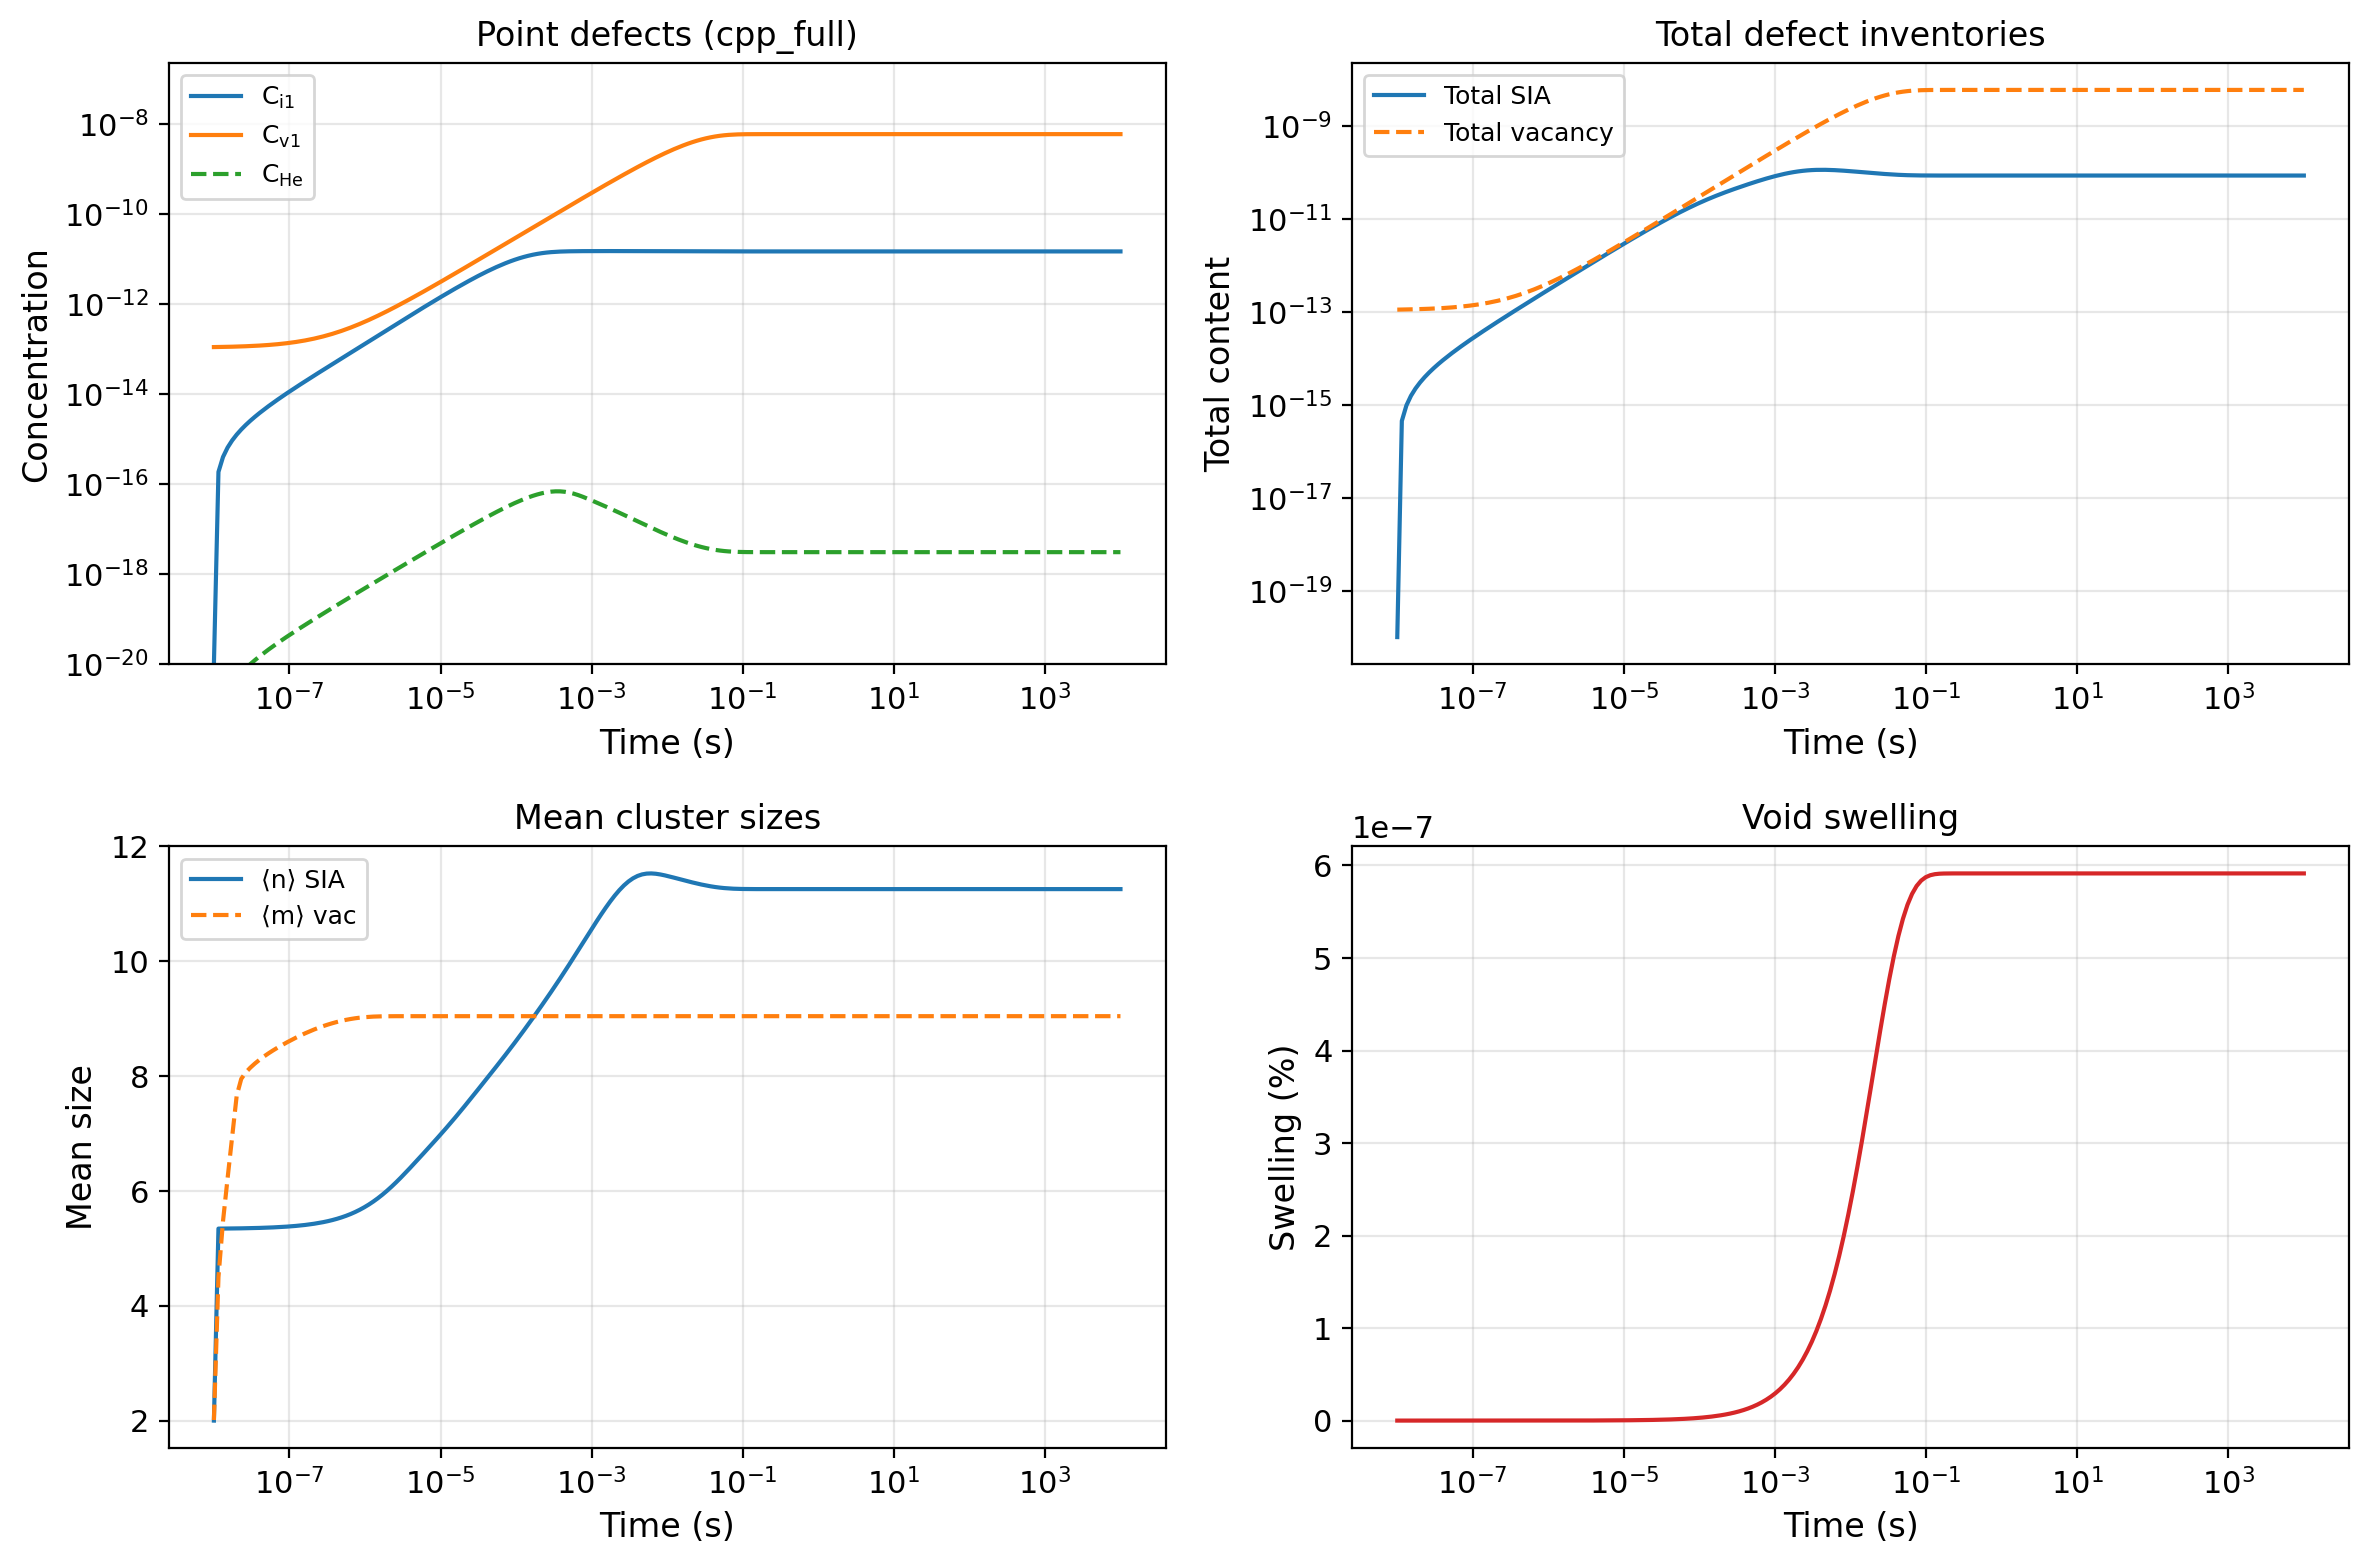

In [12]:
if MODE != 'cpp_full':
    print(f"Skipping cpp_full (MODE={MODE!r}).  Set MODE='cpp_full' to run.")
else:
    from Eurofer_CD.py_utils.cpp_bridge import run_cpp_solver

    results = run_cpp_solver(sim, SOLVER_CONFIG)

    if results is not None:
        linsol_used = SOLVER_METHOD.get('linsol', 'dense').upper()
        run_dir = create_run_directory(label=f'cpp_full_{linsol_used}')
        write_provenance(run_dir, results, sim.input_data)
        viz = EuroferCDVisualizer(results, sim.input_data, run_dir=run_dir)
        viz.plot_all()
        print(f"Output: {run_dir}")

        t   = results['time']
        c   = results['concentrations']
        tot = results['totals']
        sw  = results['swelling']

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        ax = axes[0, 0]
        ax.loglog(t, np.maximum(c['Ci1'],  1e-40), label='$C_{i1}$')
        ax.loglog(t, np.maximum(c['Cv1'],  1e-40), label='$C_{v1}$')
        ax.loglog(t, np.maximum(c['C_He'], 1e-40), label='$C_{He}$', ls='--')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Concentration')
        ax.set_title('Point defects (cpp_full)')
        ax.set_ylim(bottom=1e-20); ax.legend(); ax.grid(True, which='both', alpha=0.3)

        ax = axes[0, 1]
        ax.loglog(t, np.maximum(tot['total_i'], 1e-40), label='Total SIA')
        ax.loglog(t, np.maximum(tot['total_v'], 1e-40), label='Total vacancy', ls='--')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Total content')
        ax.set_title('Total defect inventories'); ax.legend(); ax.grid(True, which='both', alpha=0.3)

        ax = axes[1, 0]
        ms = results['mean_sizes']
        ax.semilogx(t, ms['mean_n'], label='⟨n⟩ SIA')
        ax.semilogx(t, ms['mean_m'], label='⟨m⟩ vac', ls='--')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Mean size')
        ax.set_title('Mean cluster sizes'); ax.legend(); ax.grid(True, which='both', alpha=0.3)

        ax = axes[1, 1]
        ax.semilogx(t, sw * 100, color='C3')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Swelling (%)')
        ax.set_title('Void swelling'); ax.grid(True, which='both', alpha=0.3)

        plt.tight_layout()
        plt.show()

---
## Cell 3 — C++ Phase I: upper-truncation window (`cpp_expand_front`)

In [13]:
if MODE != 'cpp_expand_front':
    print(f"Skipping cpp_expand_front (MODE={MODE!r}).")
else:
    from Eurofer_CD.py_utils.cpp_bridge import run_cpp_solver

    results = run_cpp_solver(sim, SOLVER_CONFIG)

    if results is not None:
        run_dir = create_run_directory(label='cpp_window_I')
        write_provenance(run_dir, results, sim.input_data)
        viz = EuroferCDVisualizer(results, sim.input_data, run_dir=run_dir)
        viz.plot_all()
        print(f"Output: {run_dir}")

        t = results['time']
        c = results['concentrations']

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        ax = axes[0]
        ax.loglog(t, np.maximum(c['Ci1'], 1e-40), label='$C_{i1}$')
        ax.loglog(t, np.maximum(c['Cv1'], 1e-40), label='$C_{v1}$')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Concentration')
        ax.set_title('Phase I: Point defects'); ax.legend(); ax.grid(True, alpha=0.3)

        ax = axes[1]
        tot = results['totals']
        ax.loglog(t, np.maximum(tot['total_i'], 1e-40), label='Total SIA')
        ax.loglog(t, np.maximum(tot['total_v'], 1e-40), label='Total vac', ls='--')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Total content')
        ax.set_title('Totals'); ax.legend(); ax.grid(True, alpha=0.3)

        ax = axes[2]
        ax.semilogx(t, results['swelling'] * 100, color='C3')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Swelling (%)')
        ax.set_title('Void swelling'); ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

Skipping cpp_expand_front (MODE='cpp_full').


---
## Cell 4 — C++ Phase III: constant-width sliding window (`cpp_sliding_win`)

In [14]:
if MODE != 'cpp_sliding_win':
    print(f"Skipping cpp_sliding_win (MODE={MODE!r}).")
else:
    from Eurofer_CD.py_utils.cpp_bridge import run_cpp_solver

    results = run_cpp_solver(sim, SOLVER_CONFIG)

    if results is not None:
        run_dir = create_run_directory(label='cpp_window_III')
        write_provenance(run_dir, results, sim.input_data)
        viz = EuroferCDVisualizer(results, sim.input_data, run_dir=run_dir)
        viz.plot_all()
        print(f"Output: {run_dir}")

        t = results['time']
        c = results['concentrations']

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        ax = axes[0]
        ax.loglog(t, np.maximum(c['Ci1'], 1e-40), label='$C_{i1}$')
        ax.loglog(t, np.maximum(c['Cv1'], 1e-40), label='$C_{v1}$')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Concentration')
        ax.set_title('Phase III: Point defects'); ax.legend(); ax.grid(True, alpha=0.3)

        ax = axes[1]
        tot = results['totals']
        ax.loglog(t, np.maximum(tot['total_i'], 1e-40), label='Total SIA')
        ax.loglog(t, np.maximum(tot['total_v'], 1e-40), label='Total vac', ls='--')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Total content')
        ax.set_title('Totals'); ax.legend(); ax.grid(True, alpha=0.3)

        ax = axes[2]
        ax.semilogx(t, results['swelling'] * 100, color='C3')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Swelling (%)')
        ax.set_title('Void swelling'); ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

Skipping cpp_sliding_win (MODE='cpp_full').


---
## Cell 5 — C++ Phase IV: Phase III + OpenMP (`sliding_OpenMP`)

In [15]:
if MODE != 'sliding_OpenMP':
    print(f"Skipping sliding_OpenMP (MODE={MODE!r}).")
else:
    from Eurofer_CD.py_utils.cpp_bridge import run_cpp_solver

    results = run_cpp_solver(sim, SOLVER_CONFIG)

    if results is not None:
        n_thr = SOLVER_METHOD.get('window_omp_threads', 0)
        run_dir = create_run_directory(label=f'cpp_window_IV_t{n_thr}')
        write_provenance(run_dir, results, sim.input_data)
        viz = EuroferCDVisualizer(results, sim.input_data, run_dir=run_dir)
        viz.plot_all()
        print(f"Output: {run_dir}")

        t = results['time']
        c = results['concentrations']

        fig, axes = plt.subplots(1, 3, figsize=(15, 4))
        ax = axes[0]
        ax.loglog(t, np.maximum(c['Ci1'], 1e-40), label='$C_{i1}$')
        ax.loglog(t, np.maximum(c['Cv1'], 1e-40), label='$C_{v1}$')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Concentration')
        ax.set_title(f'Phase IV (OMP {n_thr} threads): Point defects')
        ax.legend(); ax.grid(True, alpha=0.3)

        ax = axes[1]
        tot = results['totals']
        ax.loglog(t, np.maximum(tot['total_i'], 1e-40), label='Total SIA')
        ax.loglog(t, np.maximum(tot['total_v'], 1e-40), label='Total vac', ls='--')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Total content')
        ax.set_title('Totals'); ax.legend(); ax.grid(True, alpha=0.3)

        ax = axes[2]
        ax.semilogx(t, results['swelling'] * 100, color='C3')
        ax.set_xlabel('Time (s)'); ax.set_ylabel('Swelling (%)')
        ax.set_title('Void swelling'); ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

Skipping sliding_OpenMP (MODE='cpp_full').


---
## Cell 6 — Solver comparison

Run multiple cells above (different MODEs) and collect results here for comparison.

In [16]:
# Compare results from different solver runs stored in `all_results`.
# Populate manually by collecting results from Cells 1–5.
#
# Example:
#   all_results = [
#       ('Python LSODA', results_py),
#       ('C++ CVODE full', results_cpp),
#   ]

all_results = []   # populate manually

if len(all_results) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    colors = [f'C{i}' for i in range(len(all_results))]

    for (label, res), color in zip(all_results, colors):
        t   = res['time']
        c   = res['concentrations']
        tot = res['totals']
        sw  = res['swelling']

        axes[0].loglog(t, np.maximum(c['Ci1'], 1e-40),
                       label=label, color=color)
        axes[0].loglog(t, np.maximum(c['Cv1'], 1e-40),
                       ls='--', color=color)
        axes[1].loglog(t, np.maximum(tot['total_i'], 1e-40),
                       label=label, color=color)
        axes[2].semilogx(t, sw * 100, color=color, label=label)

    axes[0].set_title('Point defects (solid=Ci1, dash=Cv1)')
    axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel('Concentration')
    axes[0].legend(); axes[0].grid(True, which='both', alpha=0.3)

    axes[1].set_title('Total SIA content')
    axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('Total SIA')
    axes[1].legend(); axes[1].grid(True, which='both', alpha=0.3)

    axes[2].set_title('Void swelling')
    axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('Swelling (%)')
    axes[2].legend(); axes[2].grid(True, which='both', alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Populate `all_results` with (label, results) tuples from Cells 1–5.")

Populate `all_results` with (label, results) tuples from Cells 1–5.
